---
title: "Unsupervised Learning"
format:
    html: 
        code-fold: false
---

<!-- After digesting the instructions, you can delete this cell, these are assignment instructions and do not need to be included in your final submission.  -->

{{< include instructions.qmd >}} 

# Code

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering 

## Part 1: Dimensionality Reduction

In this section i will explore the effectiveness of two dimensionality reducing techniques for this project.

### PCA

PCA is a linear dimensionality reduction method. It combines the original features in a linear way to find the directions with the most variance. Each principal component is a weighted sum of the original features, which allows high-dimensional data to be shown in a lower dimension while keeping most of the important information. 


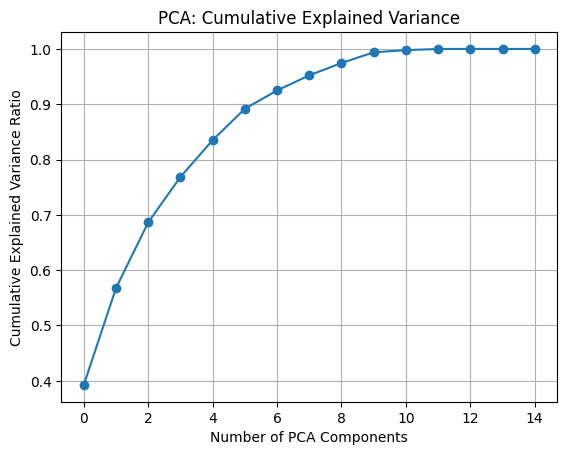

In [ ]:
# Load the dataset
df = pd.read_csv("../../data/processed-data/messi_club_detailed_cleaned.csv")

# Keep only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Standardize the data
scaled_df = StandardScaler().fit_transform(numeric_df)

# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_df)

# 5. Plot explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("PCA: Cumulative Explained Variance")
plt.grid()
plt.show()



Although the figure shows that the first 10 principal components can almost explain all of the variance, the cumulative explained variance reaches approximately 0.9 by the 5th component. The remaining components contribute very little additional information and are largely associated with noise or weak signals. To avoid unnecessary complexity and redundancy introduced by higher dimensions, while still retaining the core structure of the data, selecting the first five principal components is sufficient for effective dimensionality reduction.

In this section, I selected the first two principal components for PCA visualization. Although these two components cannot explain all the variance in the data, they capture the most important directions of variation, reflecting the overall trends and main patterns. Another key reason is that a two-dimensional plot can intuitively show the structure and distribution of high-dimensional data, making it easier to identify similarities or clustering patterns among different match samples.

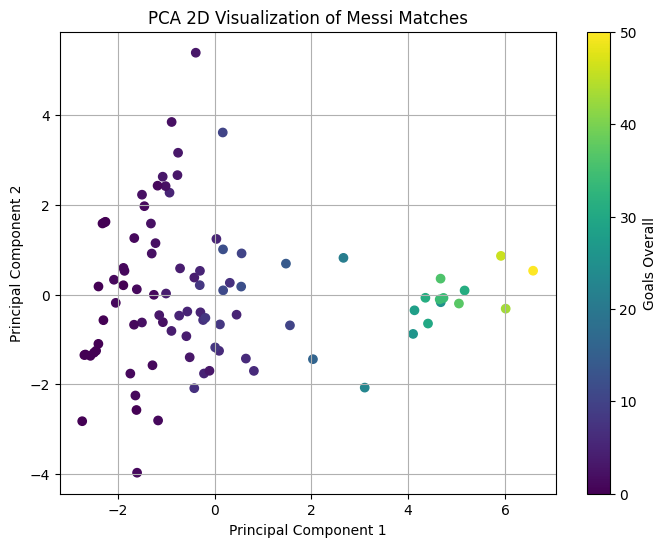

In [ ]:
# Apply PCA to reduce the data to 2D
pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(scaled_df)  # Transform the standardized numeric data


# 2D Visualization of PCA result
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    pca_2d_result[:, 0],          # X-axis: Principal Component 1
    pca_2d_result[:, 1],          # Y-axis: Principal Component 2
    c=df['goals_overall'],       
    cmap='viridis'                  
)
plt.title('PCA 2D Visualization of Messi Matches')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Goals Overall')  # Show colorbar
plt.grid(True)
plt.show()



High-goal matches are mostly found in areas with high PC1 and PC2 near zero, meaning these games have high total playing time and contributions, while efficiency is around average. Low-goal matches appear in areas with low PC1 and a wide range of PC2, showing more varied performance, with efficiency that can be high or low but overall lower total contributions.

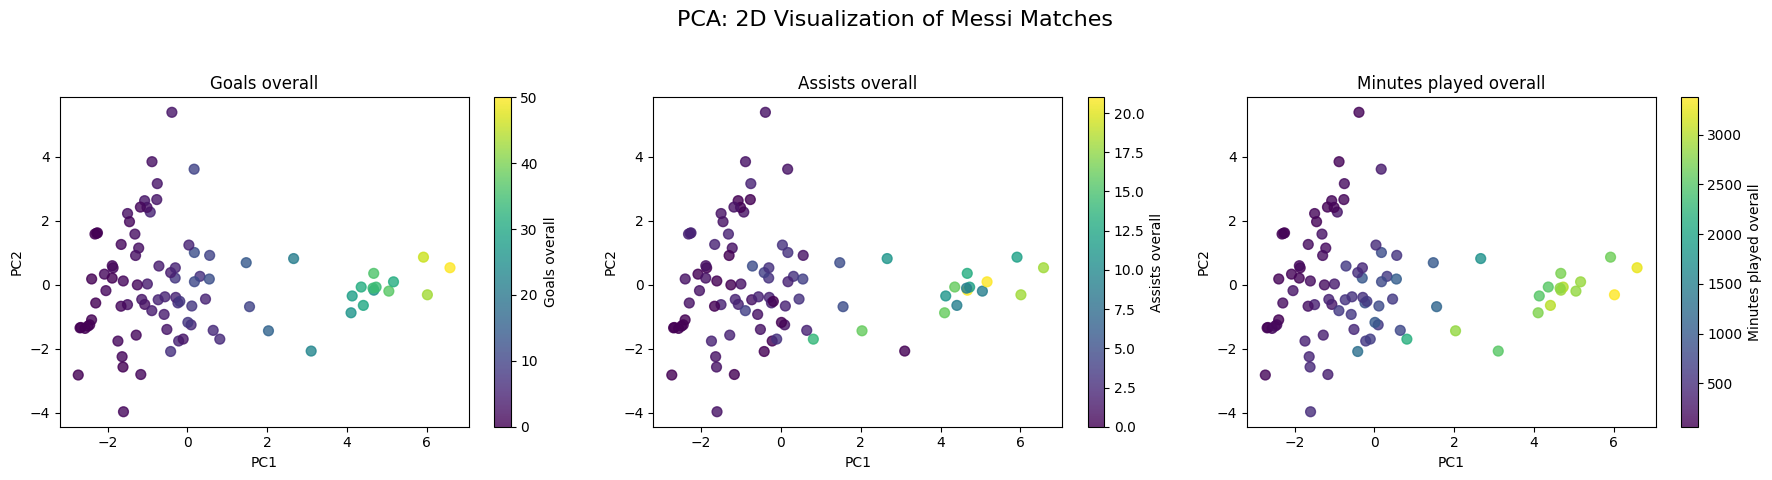

In [4]:
# Columns to visualize
rank_vars = ['goals_overall', 'assists_overall', 'minutes_played_overall']

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot each metric
for i in range(len(axes)):
    im = axes[i].scatter(
        pca_2d_result[:, 0], 
        pca_2d_result[:, 1], 
        c=df[rank_vars[i]], 
        cmap='viridis', 
        s=50, 
        alpha=0.8
    )
    fig.colorbar(im, label=rank_vars[i].replace("_", " ").capitalize(), ax=axes[i])
    axes[i].set_title(rank_vars[i].replace("_", " ").capitalize())
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')

# Main title and layout
fig.suptitle('PCA: 2D Visualization of Messi Matches', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



The three metrics of Messi's matches—total goals, total assists, and total playing time—were shown in a 2D PCA plot. Each subplot shows how these metrics spread along the first two principal components (PC1 and PC2), helping us see patterns and trends. The figure shows that matches with higher values group together, while matches with lower values group in another area. At the same time, the way the metrics change along the components shows the differences and overall performance of the matches.

### TSNE

t-SNE is a nonlinear dimensionality reduction method that maps high-dimensional data to fewer dimensions while preserving the local similarities between data points as much as possible in the lower-dimensional space. In this project, the t-SNE visualization shows distinct clusters, such as high-goal-scoring matches forming separate clusters, while low-goal-scoring matches are scattered in other areas. This indicates that t-SNE can effectively capture complex nonlinear patterns and local structures, which PCA may not be able to fully reveal. Therefore, t-SNE provides a more intuitive visualization of the potential relationships in the data, and is particularly suitable for identifying local clusters and subtle patterns.

In [5]:
# Apply t-SNE to reduce data to 2D
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
tsne_result = tsne.fit_transform(scaled_df)

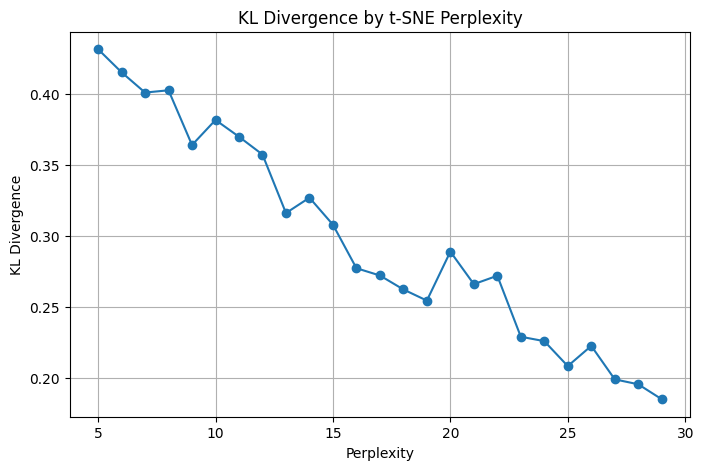

In [6]:
# Check KL divergence for different perplexity values
kl_vals = []
perps = range(5, 30)
for p in perps:
    tsne = TSNE(n_components=2, perplexity=p, random_state=24)
    tsne.fit(scaled_df)
    kl_vals.append(tsne.kl_divergence_)

# Plot KL divergence vs. perplexity
plt.figure(figsize=(8,5))
plt.plot(perps, kl_vals, marker='o', linestyle='-')
plt.title('KL Divergence by t-SNE Perplexity')
plt.xlabel('Perplexity')
plt.ylabel('KL Divergence')
plt.grid(True)
plt.show()

The KL divergence line graph shows that as perplexity increases, the KL divergence first decreases significantly, and then stabilizes within the range of 25–29, even reaching the minimum value. This indicates that within this range, t-SNE can better preserve the structure of the original high-dimensional competition data while taking into account both local and global information. Therefore, choosing perplexity = 28 as the visualization parameter is reasonable.

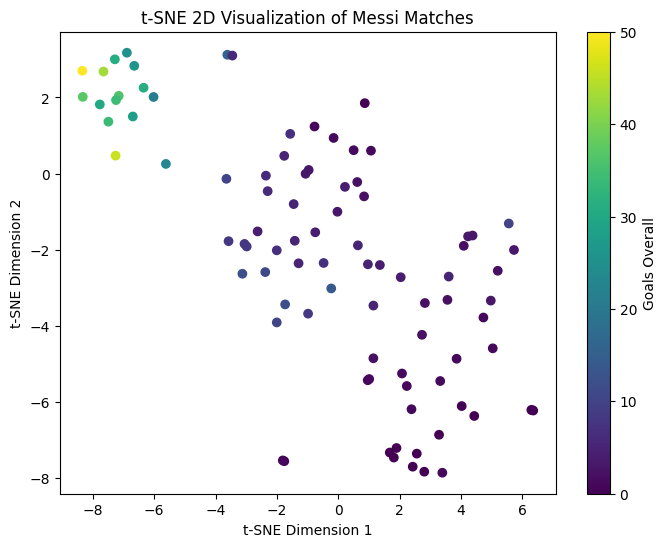

In [7]:
# Apply t-SNE to reduce the data to 2D using the chosen perplexity
tsne = TSNE(n_components=2, perplexity=28, random_state=42)  # 2D embedding with perplexity=28
tsne_result = tsne.fit_transform(scaled_df)                   # Fit and transform the standardized data

# Plot the 2D t-SNE result
plt.figure(figsize=(8,6))
plt.scatter(
    tsne_result[:,0],         
    tsne_result[:,1],         
    c=df['goals_overall'],    
    cmap='viridis'                
)
plt.colorbar(label='Goals Overall') 
plt.title('t-SNE 2D Visualization of Messi Matches')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()


The 2D visualization of t-SNE shows that the samples of games with high goals are clustered in the upper left corner of the graph, indicating that they have similar feature patterns in the high-dimensional feature space; while the samples with low goals are more scattered, suggesting that their features are quite different.

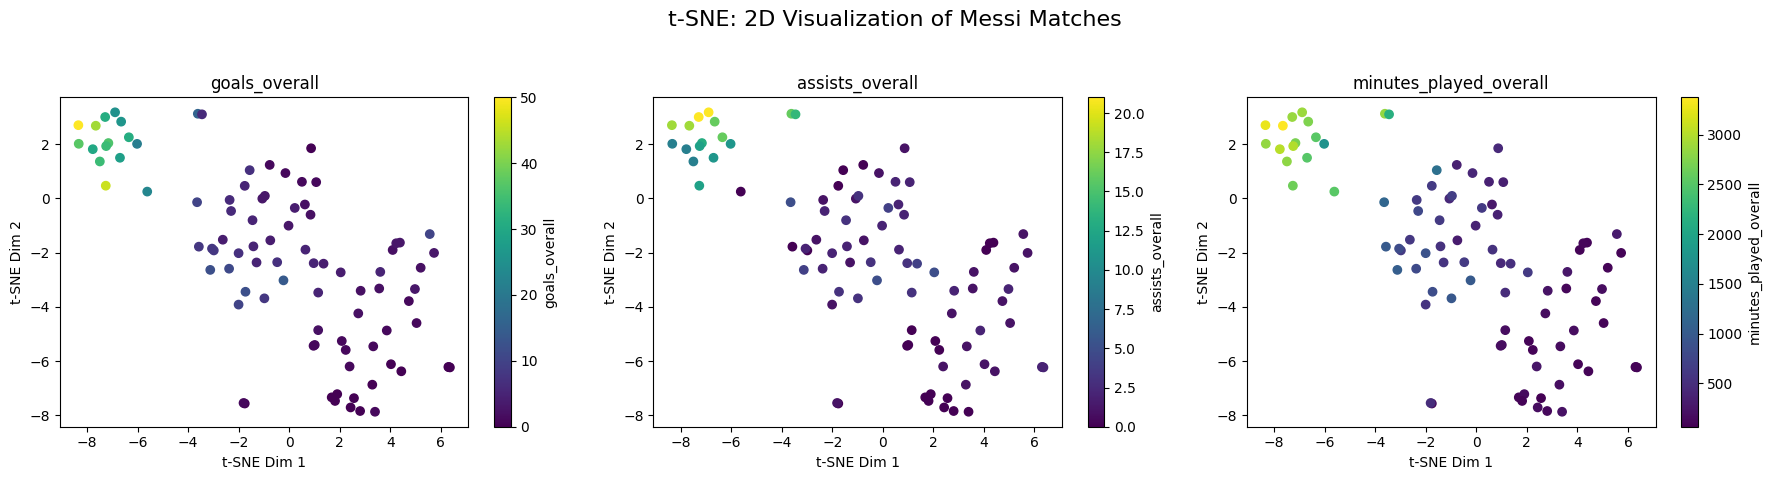

In [8]:
# Define variables to visualize on t-SNE plot
tsne_vars = ['goals_overall','assists_overall','minutes_played_overall']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Loop through each variable and plot t-SNE scatter colored by that variable
for i, var in enumerate(tsne_vars):
    im = axes[i].scatter(
        tsne_result[:,0],      
        tsne_result[:,1],       
        c=df[var],             
        cmap='viridis')
    
    fig.colorbar(im, ax=axes[i], label=var)  
    axes[i].set_xlabel('t-SNE Dim 1')
    axes[i].set_ylabel('t-SNE Dim 2')
    axes[i].set_title(var)                   

# Add overall title and adjust layout
plt.suptitle('t-SNE: 2D Visualization of Messi Matches', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In the t-SNE 2D visualization, samples with high goals scored, high assists, or a large amount of playing time form local clusters in the low-dimensional space, indicating that these games have similar feature patterns in the high-dimensional feature space.

### Evaluation

PCA and t-SNE are both commonly used dimensionality reduction methods, used to map high-dimensional data to a lower-dimensional space for visualization. However, they have distinct characteristics in terms of preserving the data structure. PCA is a linear method that can capture the global structure along the directions of maximum variance in the data. In this project, the first five principal components explain the majority of the variance, and they can linearly retain the clustering structure in the principal component space. t-SNE is a non-linear method that emphasizes maintaining local similarity and can reveal non-linear patterns and local clustering that PCA might miss. Both of these dimensionality reduction methods perform well in this dataset.

In terms of visualization capabilities, the cluster structure in the PCA graph is not as distinct as that in the t-SNE graph. t-SNE can clearly display the independent clusters formed by high-goal-scoring matches and the scattered distribution of low-goal-scoring matches, intuitively reflecting the local structure and nonlinear patterns. Overall, PCA is more suitable for analyzing the global trends and variable contributions of the data, with high computational efficiency and strong interpretability; while t-SNE is more suitable for exploring local clustering and complex patterns, but it is sensitive to parameters (such as perplexity), and the global structure is difficult to explain. The choice of which method to use should depend on the analysis goal: if the focus is on understanding the overall trend and interpretability, PCA is better; if the focus is on discovering local patterns and nonlinear relationships, t-SNE is more appropriate.

## Part 2: Clustering Methods

At this part we will apply three advanced clustering techniques to the data to uncover any groupings that exist.

### K-Means

K-Means clustering is an unsupervised learning method used to divide data into K clusters. It starts by choosing initial cluster centers (centroids), then assigns each data point to the nearest centroid. The centroids are updated as the average of points in each cluster, and this process repeats until the clusters no longer change. The goal is to make data points within the same cluster as similar as possible and data points in different clusters as different as possible.

K-Means works well when the data has clear cluster boundaries and the clusters are roughly round and similar in size. It is fast, easy to use, and performs well on large datasets. However, it also has some limits. K-Means cannot find complex shapes, is sensitive to outliers, and requires choosing the number of clusters in advance. Even so, it is one of the most widely used clustering methods because it provides quick and meaningful grouping results in many real-world tasks.

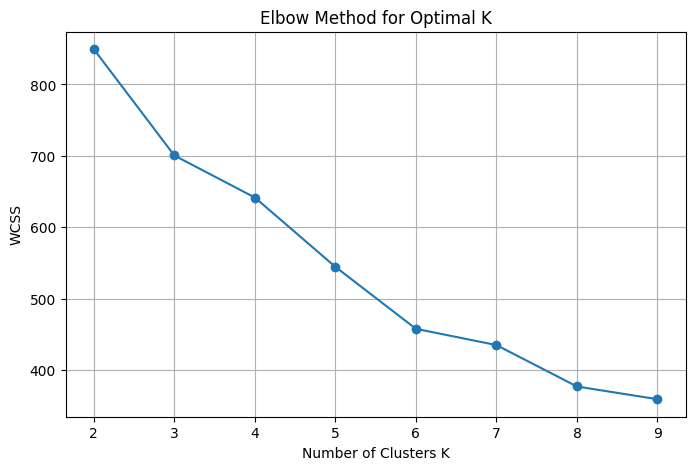

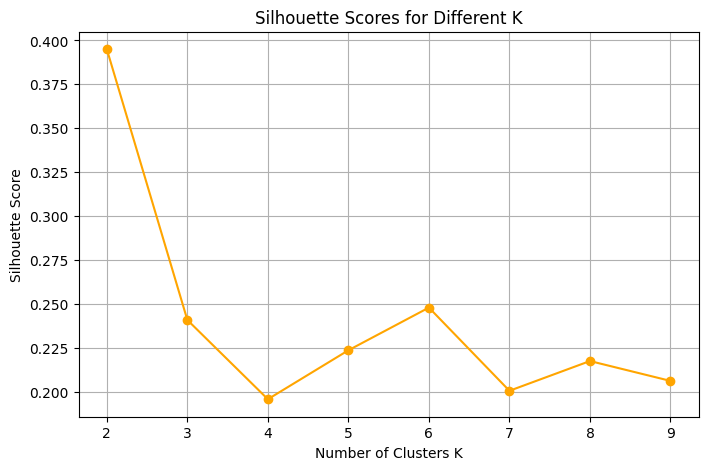

In [9]:
wcss = []          # List to store WCSS for each k
sil_scores = []    # List to store silhouette scores for each k
K_range = range(2, 10)  # Range of clusters to test

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)  # Initialize KMeans
    labels = kmeans.fit_predict(scaled_df)          # Fit and predict clusters
    wcss.append(kmeans.inertia_)                    # Store WCSS
    sil_scores.append(silhouette_score(scaled_df, labels))  # Store silhouette score

# Plot Elbow Method
plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters K')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K')
plt.grid(True)
plt.show()



Based on the Silhouette scores and the overall trend of WCSS, the most reasonable number of clusters for K-Means in this dataset is K=2. Although the WCSS curve does not show a clear elbow point, the Silhouette score reaches a relatively high value at K=2, meaning the cluster separation and cohesion are good at this point.

With K=2, the samples are divided into two groups: one group contains matches with high goals, high assists, and long playing time, while the other group contains matches with low goals and lower overall contribution.

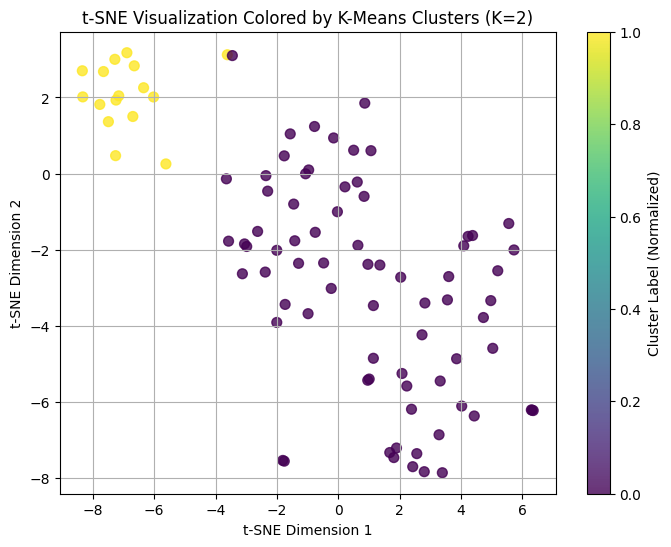

In [10]:
optimal_k = 2  # Set the optimal number of clusters

# Train K-Means and generate cluster labels
kmeans = KMeans(n_clusters=optimal_k, random_state=24)
df['kmeans_cluster'] = kmeans.fit_predict(scaled_df)  # Assign cluster labels to dataframe

# Normalize cluster labels to range 0-1 for gradient color mapping
colors_norm = df['kmeans_cluster'] / (optimal_k - 1)

# Visualize in t-SNE space using a viridis colormap
plt.figure(figsize=(8,6))
scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], 
                      c=colors_norm, cmap='viridis', s=50, alpha=0.8)
plt.title(f't-SNE Visualization Colored by K-Means Clusters (K={optimal_k})')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster Label (Normalized)')
plt.grid(True)
plt.show()


From the t-SNE visualization graph, it can be seen that the samples are clearly divided into two clusters. One cluster corresponds to samples with high goals, high assists, and high playing time, while the other cluster corresponds to samples with low goals and low contributions. However, the separation between different clusters is not obvious, and there are outliers, such as in the word "visualization" in the title, where the two points directly below the letter "n" in the middle are very close and belong to different clusters, which proves that the separation between different clusters is not complete.

### DBSCAN

DBSCAN is a density-based clustering method. It groups points that are close together and can find clusters of any shape. It does not need the number of clusters beforehand and can also identify noise or outlier points. Noise points are labeled as -1.

DBSCAN works well when the data has clusters of different shapes and densities. It can discover complex structures and separate noise points that do not belong to any cluster. One big advantage is that DBSCAN does not require choosing the number of clusters in advance. However, it also has limits. The results can change a lot depending on the parameters eps and min_samples, and it may struggle when the data has very different densities.

In [ ]:
# Initialize best parameters
best_eps = None
best_min_samples = None
best_score = -1


# Grid search for eps and min_samples
eps_values = np.arange(0.1, 4.0, 0.1)  # Range of eps values
min_samples_values = range(2, 10)      # Range of min_samples, >=2

for eps in eps_values:
    for min_samples in min_samples_values:
        # Create DBSCAN model
        dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan_model.fit_predict(scaled_df)
        
        # Only compute silhouette score if number of clusters > 1 and < total samples
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1 and n_clusters < len(df):
            score = silhouette_score(scaled_df, labels)
            # Update best parameters if current score is higher
            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples


# Output best parameters
print("Best Silhouette Score:", best_score)
print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)


Best Silhouette Score: 0.37914424713638983
Best eps: 3.1
Best min_samples: 3


Based on the results of the grid search, the optimal parameters for using DBSCAN are eps = 3.1 and min_samples = 3. At this point, the silhouette coefficient obtained from the clustering is 0.3791, indicating that the clusters are relatively compact within each other and well-separated between clusters. However, there is still some overlap or noise in the data.

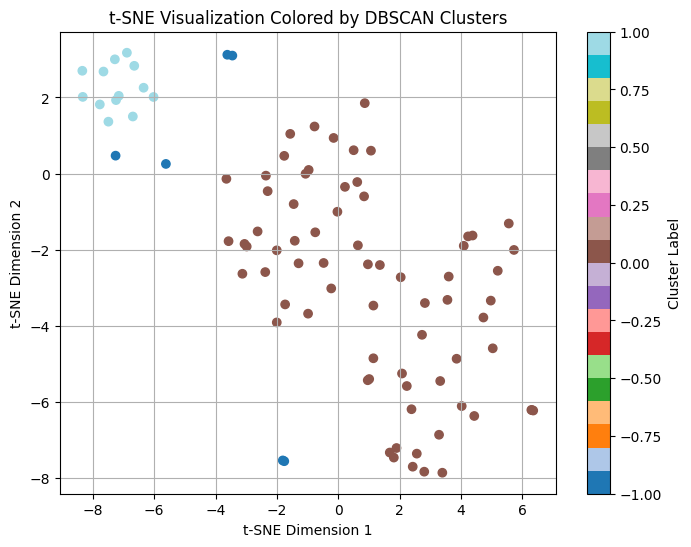

In [15]:
# fit dbscan with optimal params and add column to df
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df['dbscan_cluster'] = dbscan.fit_predict(scaled_df)

# Visualize clusters in t-SNE space
plt.figure(figsize=(8,6))
plt.scatter(
    tsne_result[:, 0], 
    tsne_result[:, 1], 
    c=df['dbscan_cluster'],          # Color by cluster label
    cmap='tab20',                    # Colormap for distinct clusters                 
)
plt.title('t-SNE Visualization Colored by DBSCAN Clusters')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

The DBSCAN clustering, trained with the optimal parameters (eps=3.1, min_samples=3), was visualized in the t-SNE two-dimensional space. Different colored points represent different clusters. The points within the same cluster are clustered together, indicating their similarity in high-dimensional features; the noise points are marked as -1, usually located outside the clusters. Overall, the clusters are closely packed within and relatively separated between each other, although there is some overlap, reflecting the complexity of the data and the medium-quality clustering quality indicated by the silhouette coefficient. Compared to K-Means, DBSCAN can better identify outliers in the data and reduce the influence of abnormal points on the clustering results, thus performing better in detecting outliers or irregular cluster structures.

### Hierarchical Clustering

Hierarchical clustering is a method that groups data in a tree-like structure. It works by either starting with each point as its own cluster and gradually merging similar clusters, or by starting with all data in one cluster and gradually splitting it into smaller clusters. This creates a hierarchy of clusters, and you can choose different levels to see how the data is grouped.

Hierarchical clustering is useful for understanding how data groups form at different levels. It does not require choosing the number of clusters in advance, and the tree structure (dendrogram) clearly shows relationships between groups. It can reveal both large, broad clusters and smaller, detailed ones. However, it can be slow on very large datasets, and once clusters are merged or split, the method cannot undo the decision. Even so, it is a helpful technique for exploring data structure and understanding natural grouping patterns.

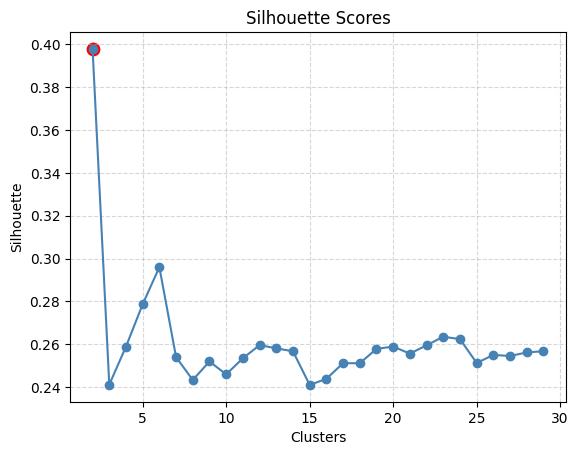

In [19]:
# initialize to hold info
n_vals = range(2, 30)
sil_scores = []

# Compute silhouette scores for each number of clusters
for n in n_vals:
    model = AgglomerativeClustering(n_clusters=n)
    labels = model.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    sil_scores.append(score)

# Convert to numpy array for easier handling
sil_scores = np.array(sil_scores)

# Find the best number of clusters
best_idx = sil_scores.argmax()
best_n = n_vals[best_idx]
best_score = sil_scores[best_idx]

# Plot the silhouette scores as a line plot
plt.plot(n_vals, sil_scores, 'o-', color='steelblue')
plt.scatter(best_n, best_score, color='red', s=80)
plt.xlabel("Clusters")
plt.ylabel("Silhouette")
plt.title("Silhouette Scores")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


By calculating the silhouette score under different cluster numbers, it was found that when the number of clusters was 2, the silhouette score reached the maximum value of 0.3978, indicating that at this point the clusters were the most compact within and the separation between clusters was the best, making it the global optimal cluster number. Meanwhile, when the number of clusters was 6, the silhouette score was 0.2960, which slightly increased compared to the previous cluster numbers, suggesting that a reasonable clustering structure could still be formed at this cluster number, and it could be regarded as a local suboptimal choice. Based on these results, the clustering results of 2 clusters and 6 clusters can be analyzed simultaneously to observe the impact of different clustering granularities on the data.

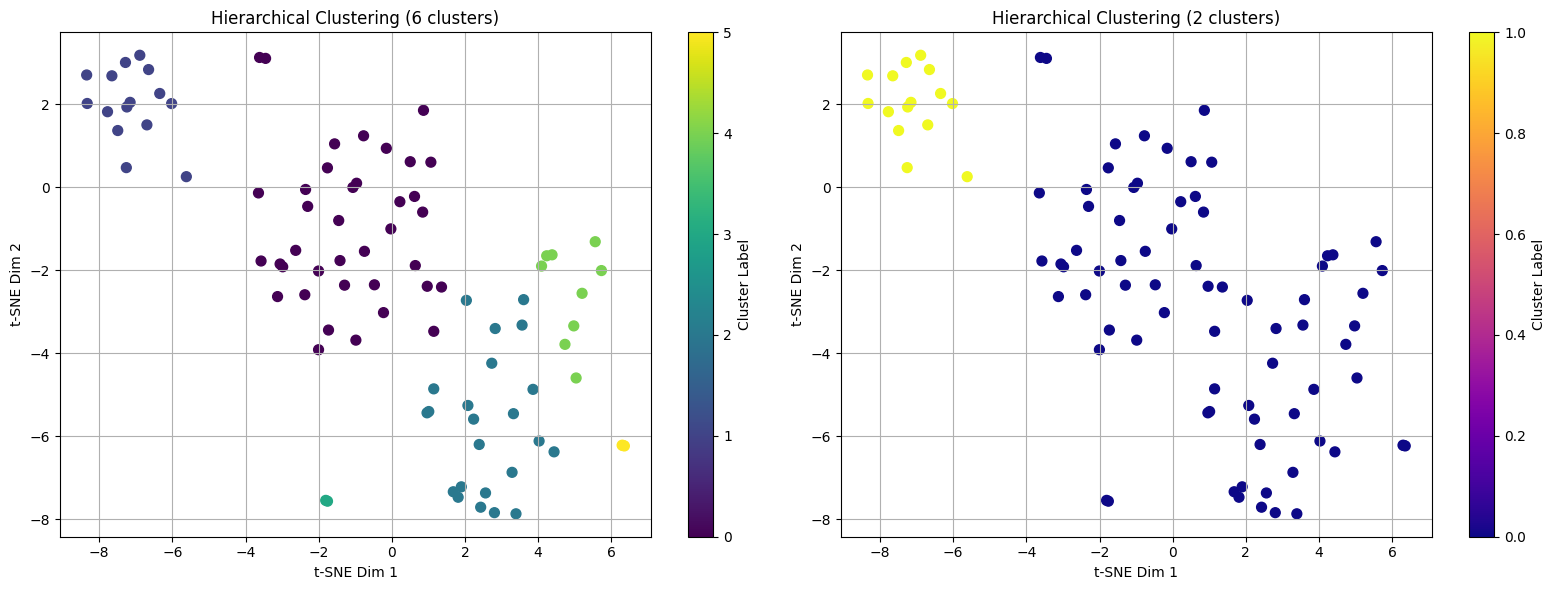

In [ ]:
# Fit Agglomerative Clustering with 6 clusters (local sub-optimal)
agg_cluster_6 = AgglomerativeClustering(n_clusters=6)
df['agg_cluster_6'] = agg_cluster_6.fit_predict(scaled_df)

# Fit Agglomerative Clustering with 2 clusters (global optimal)
agg_cluster_2 = AgglomerativeClustering(n_clusters=2)
df['agg_cluster_2'] = agg_cluster_2.fit_predict(scaled_df)

# Plot t-SNE visualizations side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 6-cluster plot
scatter1 = axes[0].scatter(tsne_result[:, 0], tsne_result[:, 1], 
                           c=df['agg_cluster_6'], cmap='viridis', s=50)
axes[0].set_title('Hierarchical Clustering (6 clusters)')
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster Label')
axes[0].grid(True)

# 2-cluster plot
scatter2 = axes[1].scatter(tsne_result[:, 0], tsne_result[:, 1], 
                           c=df['agg_cluster_2'], cmap='plasma', s=50)
axes[1].set_title('Hierarchical Clustering (2 clusters)')
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster Label')
axes[1].grid(True)

plt.tight_layout()
plt.show()



By comparing the two t-SNE visualizations, we can observe that when the number of clusters is 6, the data is divided into more and smaller clusters, revealing the local structure in greater detail. Some outliers or edge points may be separately assigned to small clusters, thereby making the clustering result more refined. However, this subdivision also leads to a decrease in the compactness within clusters and a less distinct separation between clusters compared to 2 clusters. The silhouette coefficient is only 0.2960, which is much lower than 0.3978 for 2 clusters. In contrast, when the number of clusters is 2, the samples within clusters are highly compact and the separation between clusters is obvious, resulting in a more stable overall clustering structure and higher clustering quality. Therefore, although 6 clusters can show local differences and potential outliers, from the perspective of global clustering quality and the interpretability of clusters, 2 clusters remain the best choice.

### Evaluation


In this part, I applied three clustering algorithms to the dataset - K-Means, DBSCAN and Hierarchical Clustering. The aim was to identify the natural groupings of Messi' performances based on his goals scored, assists, playing time and other characteristics. The results show that DBSCAN performs particularly well in identifying outliers and irregular cluster structures, and is more suitable for this dataset.

K-Means provides a stable global cluster structure. When the number of clusters is 2, the silhouette coefficient is the highest, indicating that the clusters are closely packed within and clearly separated between each other. It can clearly divide the players into high-performance group and low-performance group, making it suitable for observing the distribution of the overall data. 

Hierarchical Clustering exhibits excellent global clustering performance when the number of clusters is 2, similar to K-Means. When the number of clusters increases to 6, it can reveal more local structures and potential outliers, but the intra-cluster compactness decreases and the separation between clusters is not as distinct as in the 2-cluster case. Therefore, it is suitable for exploring local differences and fine-grained grouping of samples. 

DBSCAN performs best in identifying dense clusters and differentiating noise points (-1), and is capable of effectively handling abnormal sample. Although it may generate some smaller clusters or mark individual points as noise, it can clearly display the density and irregular structure of the clusters. 

Overall recommendation: For global clustering and interpretability, 2 clusters are the best choice; if focusing on abnormal players or local structures, DBSCAN or hierarchical clustering with an increased number of clusters can be used.

# Conclusions

In terms of dimensionality reduction, PCA is good at capturing global trends, with efficient calculation and easy interpretation. While t-SNE is more suitable for revealing local structures and nonlinear patterns. In terms of clustering, 2-class K-Means is best for global grouping, hierarchical clustering can detect local differences, and DBSCAN is good at identifying outliers and irregular clusters.